<center><h1>Предсказание популярности треков</h1></center>

In [1]:
import sys
from pathlib import Path 

In [2]:
sys.path.append( Path.cwd() )

In [25]:
import time 
import joblib
from pprint import pprint 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [4]:
# %pip install catboost, xgboost

In [5]:
%load_ext autoreload
%autoreload 2
    
from models import HitPrediction

## Данные 

In [6]:
data = pd.read_csv("../../data/spotify_data.csv", index_col=0)

In [7]:
data.head()

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [8]:
data["popularity"].agg({"min", "max", "mean"})

min       0.000000
max     100.000000
mean     18.383123
Name: popularity, dtype: float64

In [9]:
data.isna().sum()

artist_name         15
track_name           1
track_id             0
popularity           0
year                 0
genre                0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
dtype: int64

In [10]:
data["track_name_len"] = data["track_name"].dropna().str.len()
data["track_name_len"] = data["track_name_len"].fillna(0)

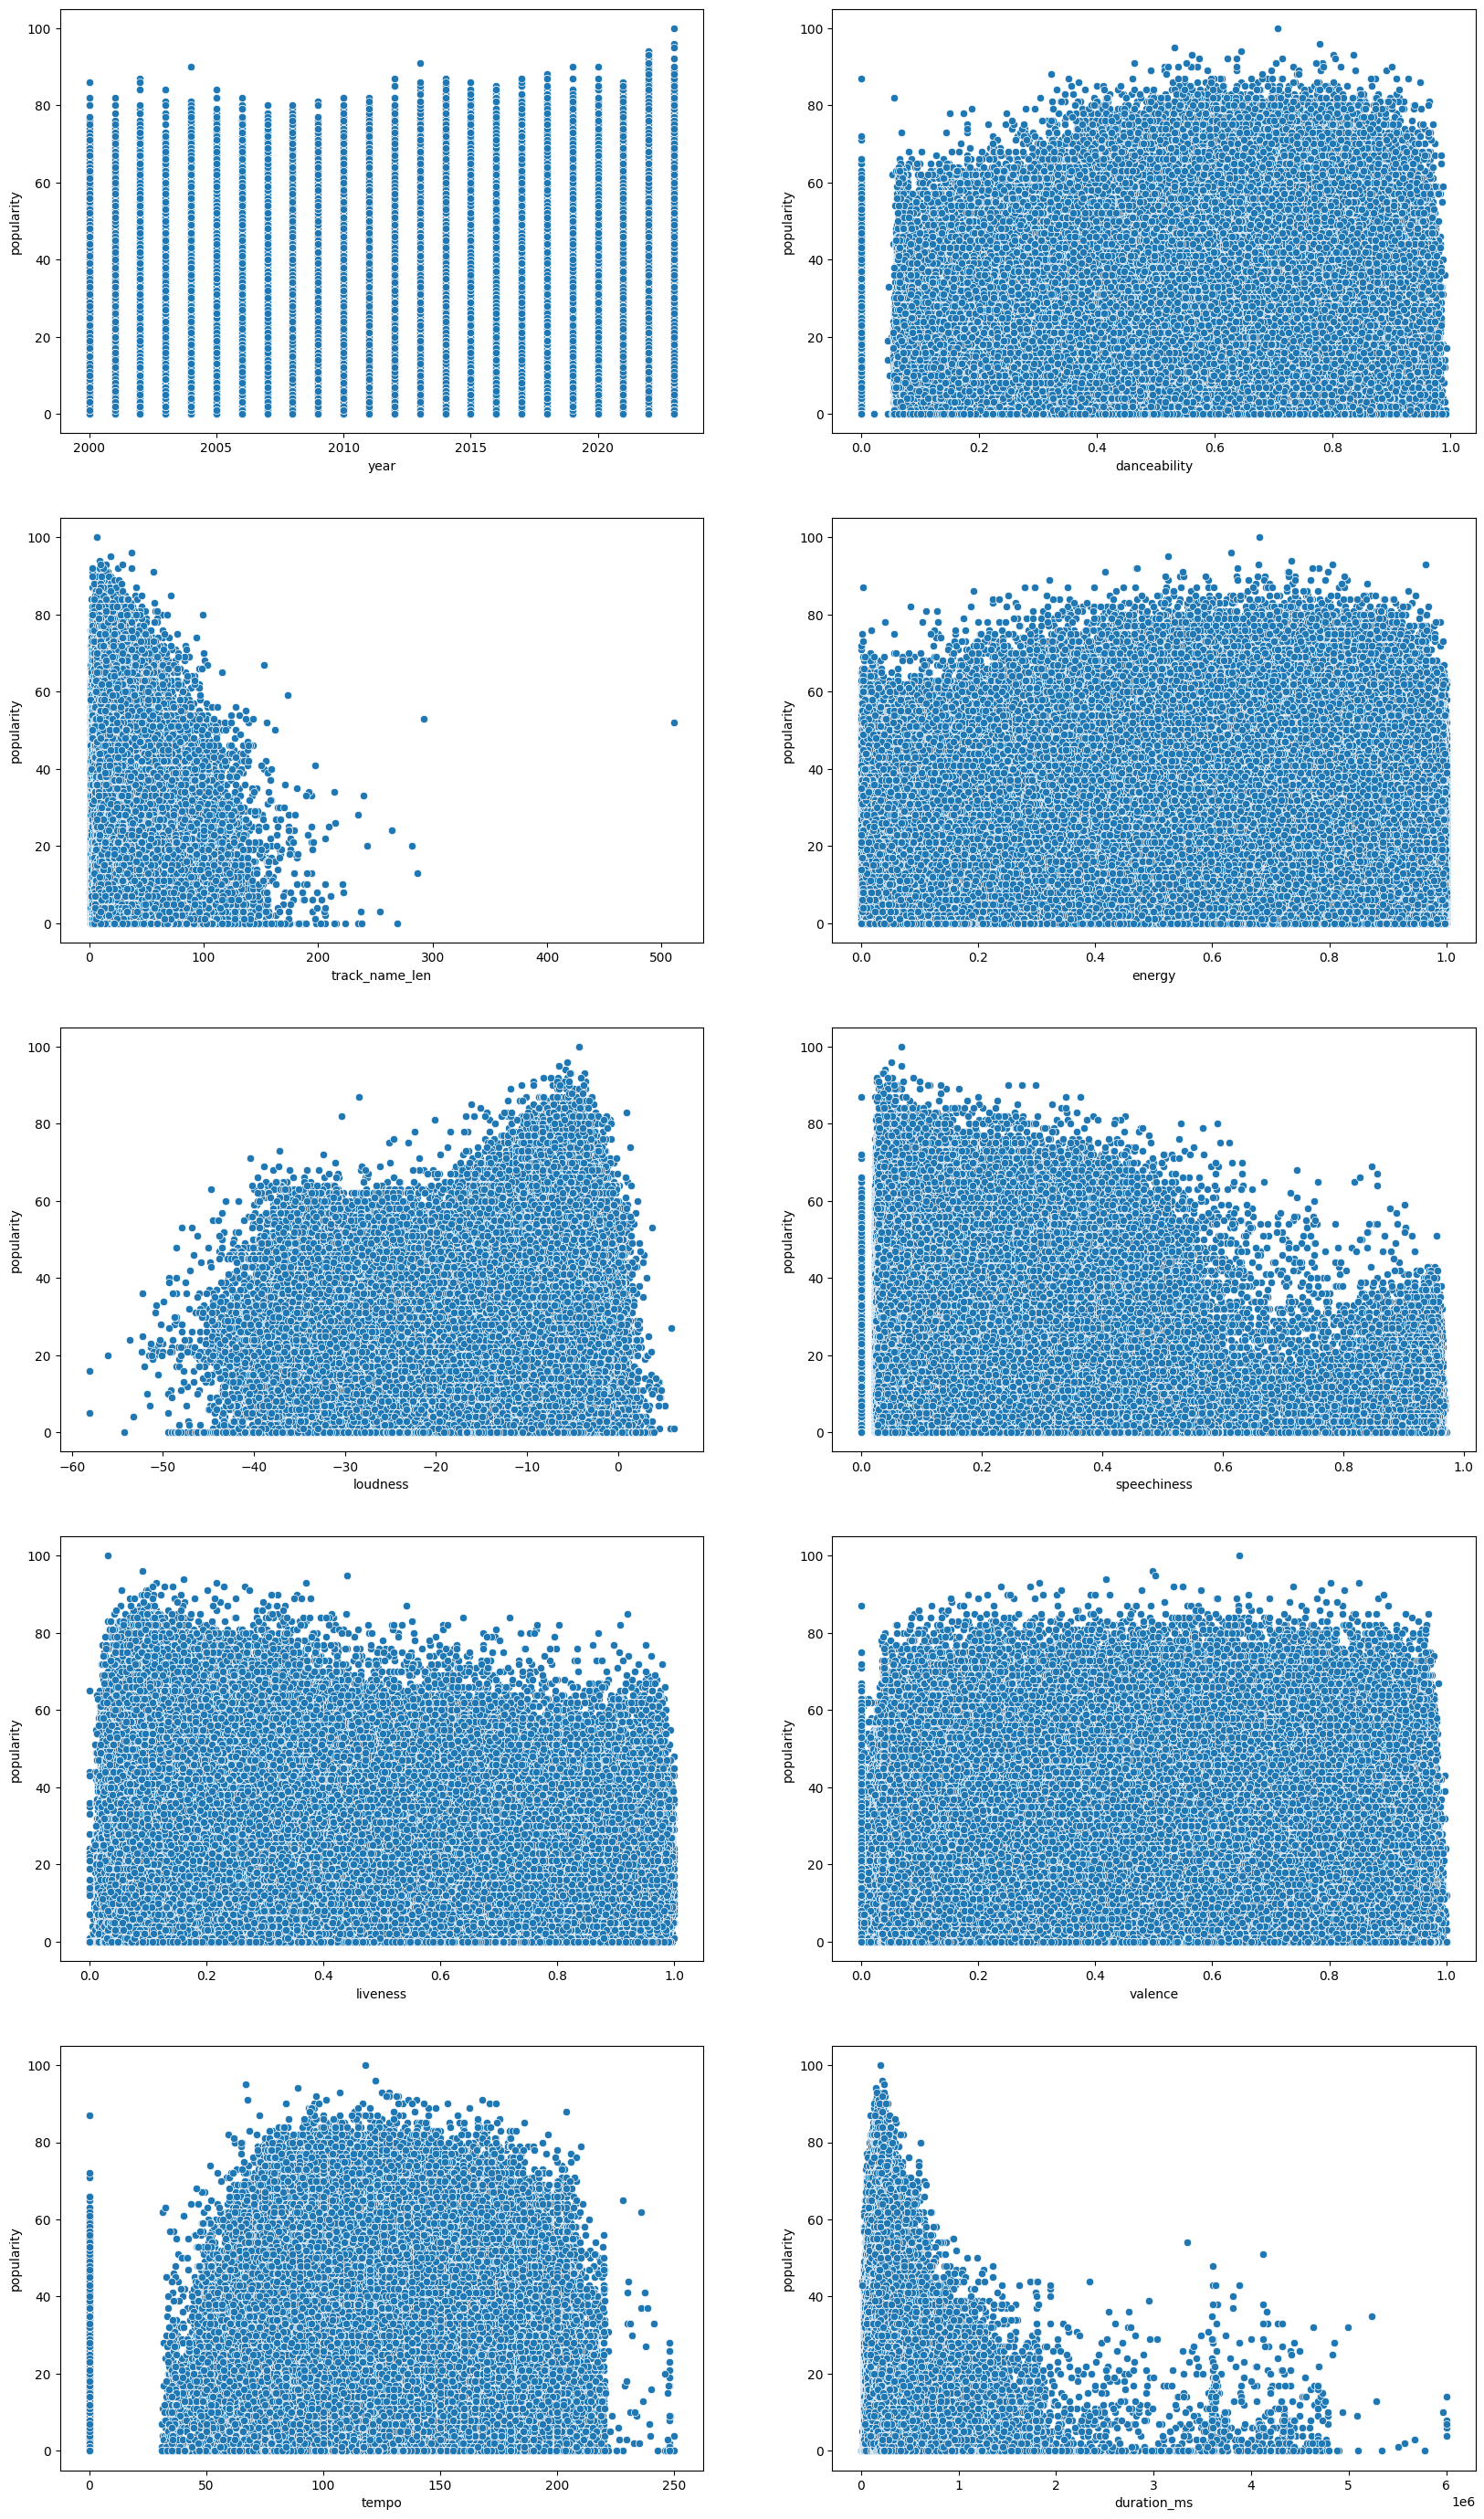

In [11]:
features_small = ['year', 'danceability', "track_name_len",
    'energy', 'loudness', 'speechiness', 
    'liveness', 'valence', 'tempo', 'duration_ms'
]

fig, axs = plt.subplots(
    ncols=2,
    nrows=len(features_small) // 2, 
    figsize=(20, 35)
)
axs = axs.ravel() 

for feature, ax in zip(features_small, axs):
    sns.scatterplot( 
        data=data,
        x=feature,
        y="popularity",
        ax=ax,
    )
plt.show()

In [12]:
# Выборка не сбалансированна 
data[data["popularity"] >= 70].shape[0] / data.shape[0]

0.0029712941598463135

In [13]:
# Уберем часть признаков  
data = data.drop(columns=["track_id", "artist_name", "track_name"])

## Запуск моделей 

In [14]:
TRGET_COL = "popularity"
FEATURE_COLS = [
    'year', 
    'genre', 
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness', 
    'valence',
    'tempo',
    'duration_ms',
    'time_signature',
    'track_name_len',
]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    data[FEATURE_COLS], data[TRGET_COL],
    test_size=0.3,
    random_state=42,
)

In [33]:
models = {
    "simple_regression": regression_model, # baseline model 
    "catboost": catboost_model, 
    "xgboost": xgboost_model,
}

In [34]:
for name, model in models.items():
    model = HitPrediction(
        features=FEATURE_COLS,
        model_type=name
    )

Обучение 

In [35]:
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    print(f"[{name}] trained in {elapsed / 60:.2f}min")

[simple_regression] trained in 0.02min
[catboost] trained in 1.33min
[xgboost] trained in 0.23min


Результаты 

In [36]:
for name, model in models.items():
    print(name)
    pprint(model.evaluate(X_test, y_test))

simple_regression
{'confusion_matrix': array([[346891,      0],
       [  1039,      0]]),
 'f1': 0.0,
 'roc_auc': 0.8251451420882046}
catboost
{'confusion_matrix': array([[346886,      5],
       [  1037,      2]]),
 'f1': 0.0038240917782026767,
 'roc_auc': 0.9481594167582642}
xgboost
{'confusion_matrix': array([[346878,     13],
       [  1029,     10]]),
 'f1': 0.018832391713747645,
 'roc_auc': 0.9513029279092029}


In [32]:
# По результатам метрик лучшая модель - XGBRegressor

Сохранение

In [22]:
folder_path = "../../data"

In [ ]:
# for name, model in models.items():
    
#     with open(f"{folder_path}/trained_{name}.pkl", "wb") as f:
#         joblib.dump(model, f)